# 14 · Model Selection & Cross-Validation

**Difficulty:** Intermediate | **Time:** ~2.5 hours

This is the most important notebook for building reliable ML models. Bad evaluation = unreliable models in production.

## Table of Contents
1. Train/Test Split — The Baseline
2. Cross-Validation (K-Fold)
3. Stratified CV for Imbalanced Data
4. Comparing Multiple Models
5. Bias-Variance Trade-off Visualized
6. Model Selection Best Practices
7. Final Evaluation Protocol

## 1. The Problem with a Single Train/Test Split

Single split repeated 20 times:
  Min accuracy: 94.74%
  Max accuracy: 99.12%
  Range:        4.4 percentage points

This variance is LUCK, not model quality!


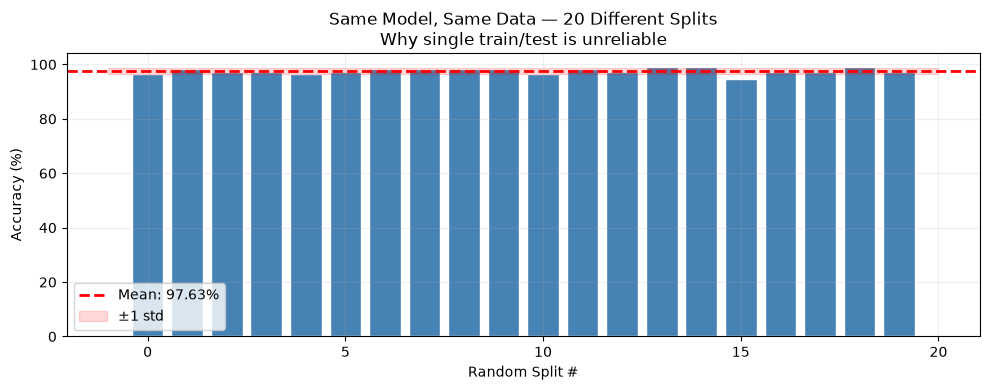

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold,
                                      cross_val_score, cross_validate,
                                      GridSearchCV, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, r2_score
from sklearn.datasets import load_breast_cancer, load_wine
import warnings
warnings.filterwarnings('ignore')

# Show variance in single train/test split
bc = load_breast_cancer()
X, y = bc.data, bc.target
sc = StandardScaler()
X_s = sc.fit_transform(X)

# Run the same model 20 times with different random splits
accs = []
for seed in range(20):
    X_tr, X_te, y_tr, y_te = train_test_split(X_s, y, test_size=0.2, random_state=seed)
    lr = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
    accs.append(lr.score(X_te, y_te))

print(f"Single split repeated 20 times:")
print(f"  Min accuracy: {min(accs):.2%}")
print(f"  Max accuracy: {max(accs):.2%}")
print(f"  Range:        {(max(accs)-min(accs))*100:.1f} percentage points")
print(f"\nThis variance is LUCK, not model quality!")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(20), [a*100 for a in accs], color='steelblue', edgecolor='white')
ax.axhline(np.mean(accs)*100, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(accs):.2%}')
ax.fill_between([-1, 20], [(np.mean(accs)-np.std(accs))*100]*2,
                [(np.mean(accs)+np.std(accs))*100]*2, alpha=0.15, color='red', label='±1 std')
ax.set_xlabel("Random Split #"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Same Model, Same Data — 20 Different Splits\nWhy single train/test is unreliable")
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("/tmp/split_variance.png", dpi=100)
plt.show()

## 2. K-Fold Cross-Validation — The Solution

  Fold 1: 455 train, 114 val → Acc=97.37%
  Fold 2: 455 train, 114 val → Acc=98.25%
  Fold 3: 455 train, 114 val → Acc=96.49%
  Fold 4: 455 train, 114 val → Acc=99.12%
  Fold 5: 456 train, 113 val → Acc=97.35%

CV Mean: 97.71% ± 0.90%
This is much more reliable than a single split!


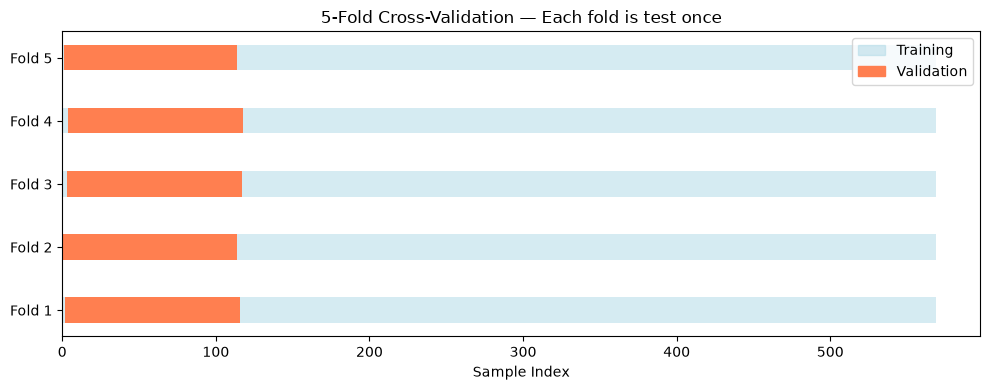

In [2]:
# K-Fold: split into K parts, rotate test set
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_accs = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X_s)):
    X_tr, X_val = X_s[train_idx], X_s[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    lr = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
    acc = lr.score(X_val, y_val)
    fold_accs.append(acc)
    print(f"  Fold {fold+1}: {len(train_idx)} train, {len(val_idx)} val → Acc={acc:.2%}")

print(f"\nCV Mean: {np.mean(fold_accs):.2%} ± {np.std(fold_accs):.2%}")
print(f"This is much more reliable than a single split!")

# Visualize K-Fold
fig, ax = plt.subplots(figsize=(10, 4))
n = len(X_s)
fold_size = n // 5

for fold_i, (tr, val) in enumerate(kf.split(X_s)):
    row_y = fold_i
    # Training indices
    ax.barh(row_y, n, left=0, height=0.4, color='lightblue', alpha=0.5)
    # Validation indices (highlighted)
    val_start = min(val)
    ax.barh(row_y, len(val), left=val_start, height=0.4, color='coral', label='Validation' if fold_i==0 else '')

ax.set_yticks(range(5))
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_xlabel("Sample Index")
ax.set_title("5-Fold Cross-Validation — Each fold is test once")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='lightblue', alpha=0.5, label='Training'),
                    Patch(color='coral', label='Validation')])
plt.tight_layout()
plt.savefig("/tmp/kfold.png", dpi=100)
plt.show()

## 3. Comparing Multiple Models with CV

Logistic Regression      : 0.981 ± 0.015
Decision Tree            : 0.928 ± 0.033


Random Forest            : 0.963 ± 0.031


Gradient Boosting        : 0.961 ± 0.029
SVM (RBF)                : 0.977 ± 0.022


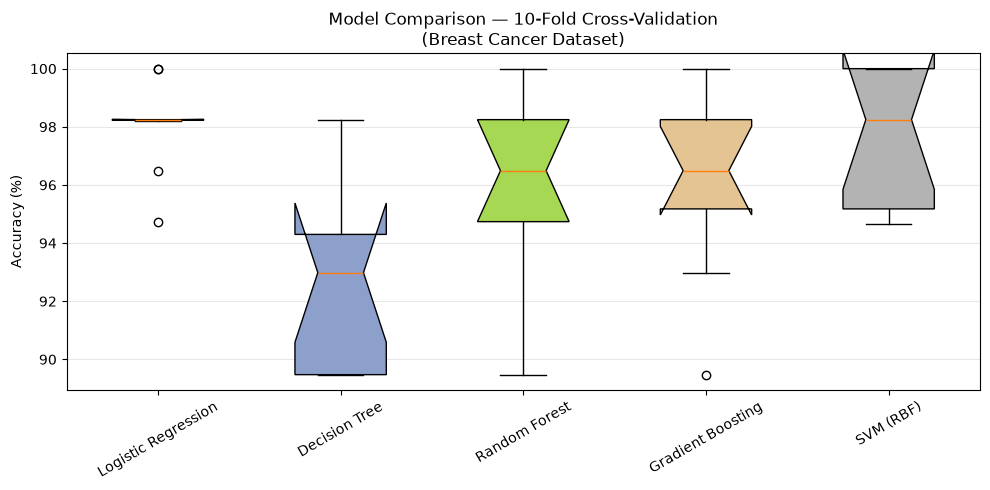

In [3]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)'           : SVC(kernel='rbf', probability=True),
}

results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_s, y, cv=10, scoring='accuracy', n_jobs=-1)
    results[name] = cv_scores
    print(f"{name:<25}: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Box plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
bp_data  = [results[m] * 100 for m in models]
bp_names = list(models.keys())

bp = ax.boxplot(bp_data, tick_labels=bp_names, patch_artist=True, notch=True)
colors = plt.cm.Set2(np.linspace(0, 1, len(models)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Comparison — 10-Fold Cross-Validation\n(Breast Cancer Dataset)")
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("/tmp/model_comparison.png", dpi=100)
plt.show()

## 4. Bias-Variance Trade-off

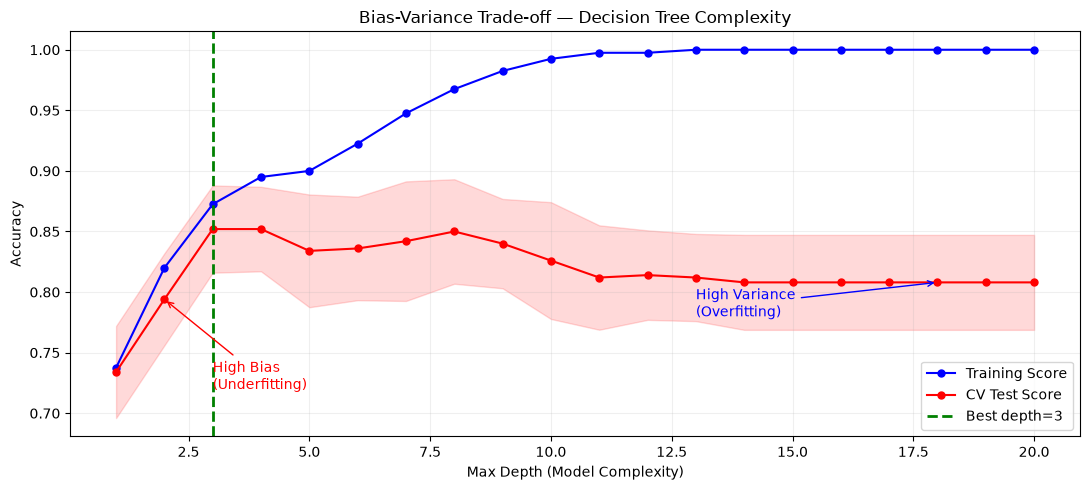

In [4]:
from sklearn.datasets import make_classification

np.random.seed(42)
X_bv, y_bv = make_classification(n_samples=500, n_features=20, n_informative=10,
                                   n_redundant=5, random_state=42)
sc_bv = StandardScaler()
X_bvs = sc_bv.fit_transform(X_bv)

# Test different complexity levels for Decision Tree
depths = range(1, 21)
train_scores_mean = []
test_scores_mean  = []
test_scores_std   = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    # Training score (no CV needed)
    X_tr, X_te, y_tr, y_te = train_test_split(X_bvs, y_bv, test_size=0.2, random_state=42)
    dt.fit(X_tr, y_tr)
    train_scores_mean.append(dt.score(X_tr, y_tr))
    # CV score for test
    cv = cross_val_score(dt, X_bvs, y_bv, cv=10)
    test_scores_mean.append(cv.mean())
    test_scores_std.append(cv.std())

fig, ax = plt.subplots(figsize=(11, 5))
test_m = np.array(test_scores_mean)
test_s = np.array(test_scores_std)

ax.plot(depths, train_scores_mean, 'b-o', ms=5, label='Training Score')
ax.plot(depths, test_m, 'r-o', ms=5, label='CV Test Score')
ax.fill_between(depths, test_m - test_s, test_m + test_s, alpha=0.15, color='red')
ax.axvline(depths[np.argmax(test_m)], color='green', linestyle='--', linewidth=2,
            label=f"Best depth={depths[np.argmax(test_m)]}")

# Annotate regions
ax.annotate('High Bias\n(Underfitting)', xy=(2, test_m[1]),
             xytext=(3, 0.72), fontsize=10, color='red',
             arrowprops=dict(arrowstyle='->', color='red'))
ax.annotate('High Variance\n(Overfitting)', xy=(18, test_m[-3]),
             xytext=(13, 0.78), fontsize=10, color='blue',
             arrowprops=dict(arrowstyle='->', color='blue'))

ax.set_xlabel("Max Depth (Model Complexity)")
ax.set_ylabel("Accuracy")
ax.set_title("Bias-Variance Trade-off — Decision Tree Complexity")
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("/tmp/bias_variance.png", dpi=100)
plt.show()

## 5. Hyperparameter Search — GridSearch vs RandomSearch

In [5]:
from scipy.stats import randint, uniform

# Grid Search — exhaustive
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
}

rf = RandomForestClassifier(random_state=42)
grid_cv = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_cv.fit(X_s, y)

print("Grid Search:")
print(f"  Best params: {grid_cv.best_params_}")
print(f"  Best CV score: {grid_cv.best_score_:.2%}")
print(f"  Total fits: {len(grid_cv.cv_results_['mean_test_score'])}")

# Random Search — often finds equally good params faster
param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth'   : [5, 10, 20, 30, None],
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', None]
}

rand_cv = RandomizedSearchCV(rf, param_dist, n_iter=30, cv=5,
                               scoring='accuracy', random_state=42, n_jobs=-1)
rand_cv.fit(X_s, y)

print("\nRandom Search:")
print(f"  Best params: {rand_cv.best_params_}")
print(f"  Best CV score: {rand_cv.best_score_:.2%}")
print(f"  Total fits: 30 (same quality, much faster than {3*4*3}=36)")

Grid Search:
  Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
  Best CV score: 96.31%
  Total fits: 36



Random Search:
  Best params: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 8, 'n_estimators': 90}
  Best CV score: 96.49%
  Total fits: 30 (same quality, much faster than 36=36)


## 6. The Correct Evaluation Protocol

In [6]:
# WRONG: tune on test set, then report test accuracy
# RIGHT: use nested CV or a held-out test set never touched during tuning

# Correct Protocol:
# 1. Split: train (60%) | validation (20%) | test (20%)  — test NEVER touched
# 2. Train models on train set, tune on validation
# 3. Report FINAL accuracy on test set ONCE

X_tr, X_holdout, y_tr, y_holdout = train_test_split(X_s, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val   = train_test_split(X_tr, y_tr, test_size=0.25, random_state=42)

print("Dataset splits:")
print(f"  Training  : {len(X_train)} samples")
print(f"  Validation: {len(X_val)} samples")
print(f"  Holdout   : {len(X_holdout)} samples (NEVER TOUCH until final)")

# Tune on validation
best_acc, best_model = 0, None
for n_est in [50, 100, 200]:
    for depth in [5, 10, None]:
        rf = RandomForestClassifier(n_estimators=n_est, max_depth=depth, random_state=42)
        rf.fit(X_train, y_train)
        acc = rf.score(X_val, y_val)
        if acc > best_acc:
            best_acc, best_model = acc, rf
            best_cfg = (n_est, depth)

print(f"\nBest config: n_estimators={best_cfg[0]}, max_depth={best_cfg[1]}")
print(f"Validation accuracy: {best_acc:.2%}")
print(f"\nFinal holdout accuracy: {best_model.score(X_holdout, y_holdout):.2%}")
print("↑ This is the REAL performance estimate")

Dataset splits:
  Training  : 341 samples
  Validation: 114 samples
  Holdout   : 114 samples (NEVER TOUCH until final)



Best config: n_estimators=200, max_depth=5
Validation accuracy: 96.49%

Final holdout accuracy: 95.61%
↑ This is the REAL performance estimate


## Summary — Rules to Never Break

```
✓ ALWAYS use cross-validation, not a single split
✓ NEVER tune hyperparameters on test data
✓ Keep a FINAL holdout test set untouched until the very end
✓ Use stratified CV for imbalanced classes
✓ Report mean ± std of CV scores
✓ Compare models with CV, not single test splits

✗ NEVER report training accuracy as model quality
✗ NEVER do feature selection on the full dataset before CV
✗ NEVER use the test set more than once
```

**Next notebook →** `15_Neural_Networks_Introduction.ipynb`